# CAPS INSPECTION
## Cavity number preprocessing
Students should develop a software program to preprocess an image and get it ready to perform the
OCR of the cavity number of a plastic cap.
The cap has an external tab (1) at a fixed position in relation to the cavity number (2). Find in
Figure 6 a picture of the external side of the cap and in Figure 7 the image to be preprocessed.

![image info](displayed.png)

## Imports and setup

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import sys
from os import listdir
import time

# Only for jupyter notebook visualization
%matplotlib inline 

## Displaying sample image
folder_path='./img/'
filename="./img/g_10.bmp"
image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.show()

### Assumptions
#### After reading the assignment and a meeting with the tutors, we made a series of assumptions: 

1. The images are acquired in an industrial enviroment: in an industrial image, typically we have a well-defined background 1+ objects, with high contrast between them.

- Plotting the grey-level histogram for an image, we can see that pixels are distributed into two well-separated classes, as it typically is the case for an industrial image. Also, because of this, images can be binarized by thresholding the pixel intensity level. We will exploit this in our first approaches and in the final solution for Task 1.

In [ ]:
hist, bins = np.histogram(image.flatten(), 256, [0,256])
plt.plot(hist)

2. There is always only one cap for each image 

We create custom datasets that pupousely go agains this assumptions in order to better understand the robustness of our solution. This discussion can be saw at the end of the notebook.

## Task 1: Generate a crop of the cavity number
### 1.1: Outline the cap by generating a circle that fits the cap mouth

In order to detect a circle that fits the cap in the image, we will use the specialization of the Hough Transform (HT) for circle shapes.

#### 1) First approach: setting min Radius and maxRadius parameters
In our first approach to the task, we used the HT by setting a minimum and a maximum radius values (i.e. the range of radius values) that we saw fit for some images. However, this naive approach will may not find correct circles (or any circle at all) for all images, due to the various defective cap images we have in the dataset.

In [98]:
mypath='./img/'
def task1_naiveCHT(filename, image, i):
    rows = image.shape[0]
    circles = cv2.HoughCircles(image, 
                           cv2.HOUGH_GRADIENT, 
                           1, 
                           rows/32,
                           minRadius=227,
                           maxRadius=250)

    if circles is not None:
        if len(circles) == 1:
            hough_circle = circles[0][0]
            center = [hough_circle[0], hough_circle[1]]
            radius = hough_circle[2]
            center_in_pixels = np.int16(np.around(center))
            radius_in_pixels = np.int16(np.around(radius))

            # Print the circle fitting cap mouth
            circle = plt.Circle(center, radius, color='m', fill=False)
            center_patch = plt.Circle(center, 1, color="g")

            ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
            ax.set_title(filename)
            ax.add_patch(center_patch)
            ax.add_patch(circle)
            ax.imshow(image, cmap='gray', vmin=0, vmax=255)

        else:
            print(f"Found {len(circles)} circles, they are too many")
            # sys.exit(1)
    else:
        print(f"No circles for image: {filename}")
        # sys.exit(1)

In [ ]:
plt.figure(figsize=(40,40))
for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    task1_naiveCHT(file, image, i)
    
plt.show()

#### 2) Second approach: binarization and setting param1 and param2 parameters
In our second approach:
- first, we binarize cap images by thresholding by pixel intensities;
- then we mask the tab out, in order to find more correct circles in the binarized images;
- finally, we set the two parameters "param1" and "param2", respectively representing the higher gradient threshold used by the Canny edge detector applied to the image, and the accumulator threshold for the circle centers.


In [ ]:
from os import listdir

mypath='./img/'
plt.figure(figsize=(40,40))
    
for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file

    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 40, 255, cv2.THRESH_BINARY)
    image_bin_rot = cv2.rotate(image_bin, cv2.ROTATE_180)
    rows = image.shape[0]
    
    #
    image_masked = np.minimum(image_bin, image_bin_rot)

    circles = cv2.HoughCircles(image_masked, 
                            cv2.HOUGH_GRADIENT, # Detection method unique that is implemented
                            1, 
                            rows/4,
                            param1=500, # Threshold on the gradient
                            param2=25) # Smaller find more false positives

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/3)), 3, i+1)
    ax.set_title(file)
    if circles is not None:
        if len(circles[0]) > 1:
            print(f"Image {file} has 2 or more circles")
        for circle in circles[0]:
            center = [circle[0], circle[1]]
            radius = circle[2]
            center_in_pixels = np.int16(np.around(center))
            radius_in_pixels = np.int16(np.around(radius))
            circle = plt.Circle(center, radius, color='m', fill=False)
            ax.add_patch(circle)
    else:
        print(f"Image {file} has no circles")   
    
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    # hist, _ = np.histogram(image.flatten(), 256, [0,256])
    # ax.stem(hist)

plt.show()

This second version finds circles for all images, but many of them are quite imprecise, again due to the various defective cap images we have in the dataset.
Tuning the HoughCircles() parameters will help us find the correct circles.

#### 3) Deleting grey objects around the cap to cancel out spurious circles
In order to find better and more precise circles, we can think of cancelling out the grey objects on the image corners, using black rectangular shapes, to leave the binarized cap only and avoid spurious circles in the image.  

In [ ]:
from os import listdir

mypath='./img/'
plt.figure(figsize=(40,40))
    
for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file

    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)
    #image_bin = image
    rows = image.shape[0]
    
    cv2.rectangle(image_bin, (0,0), (150, 600), 0, -1)
    cv2.rectangle(image_bin, (650,0), (800, 600), 0, -1)
    cv2.rectangle(image_bin, (0,0), (800, 50), 0, -1)

    circles = cv2.HoughCircles(image_masked, 
                            cv2.HOUGH_GRADIENT, # Detection method unique that is implemented
                            1, 
                            rows/8,
                            param1=500, # Theshold on the gradient
                            param2=25) # Smaller find more false positives

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/3)), 3, i+1)
    ax.set_title(file)
    if circles is not None:
        if len(circles[0]) > 1:
            print(f"Image {file} has 2 or more circles")
        for circle in circles[0]:
            center = [circle[0], circle[1]]
            radius = circle[2]
            center_in_pixels = np.int16(np.around(center))
            radius_in_pixels = np.int16(np.around(radius))
            circle = plt.Circle(center, radius, color='m', fill=False)
            ax.add_patch(circle)
    else:
        print(f"Image {file} has no circles")   

    # contours, _ = cv2.findContours(image_bin, 1, 2)
    # cnt = contours[-1]
    # (x,y),radius = cv2.minEnclosingCircle(cnt)
    # center = (int(x),int(y))
    # radius = int(radius)
    # circle = plt.Circle(center, radius, color='b', fill=False)
    # ax.add_patch(circle)
    
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.show()

This approach shows good results, even for defective caps, but it is very much dependant on the fact that we know the Region of Interest: if we get quite translated caps, this approach would cut off the cap. We would like to have a more robust solution.

#### 3) Final solution: Erosion on binarized image, and HT for circles  

After a few attempts, we saw that applying erosion on the binarized image can be quite effective in finding the circles we need, without adding much cost:
1. we binarize the image, as seen before, choosing an appropriate threshold.
2.  we apply erosion once using a 3x3 square structuring element. The eroded image is then subtracted to the original image, obtaining well defined circular contours.
3. we find the radius of the circle by looking for white pixels in the middle vertical line, and delimiting the diameter.
4. we apply the HT, choosing appropriate parameters. Apart from the choices previously discussed:
    - we apply a parameter search on param2 for more robustness.
    - we search circles considering their radius in a range close to the found cap radius, to avoid spurious circles.

In [ ]:
plt.figure(figsize=(40,40))
    
for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file

    ## 1. binarization by thresholding the pixel intensity
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    # 2. applying erosion on the binarized image, and then subtracting the result to the original binarized image
    edge_detected_image = image_bin - cv2.morphologyEx(image_bin, cv2.MORPH_ERODE, np.ones((3,3), np.uint8), iterations=1)

    # 3. finding the cap radius by search in the middle vertical line
    middle_line = edge_detected_image[:, int(edge_detected_image.shape[1]/2)]
    non_zero_indices = np.nonzero(middle_line)[0]
    diameter = non_zero_indices[-1]-non_zero_indices[0]
    radius = int(diameter/2)

    # edge_detected_image[:, 0:int(edge_detected_image.shape[1]/2) - int(radius*1.05)] = 0
    # edge_detected_image[:, int(edge_detected_image.shape[1]/2) + int(radius*1.05):] = 0

    # edge_detected_image[0:int(edge_detected_image.shape[0]/2) - int(radius*1.1), :] = 0
    # edge_detected_image[int(edge_detected_image.shape[0]/2) + int(radius*1.1):, :] = 0
    rows = image.shape[0]
    found = False
    par2 = 20
    while not found and par2 > 5:
        # 4. applying HT for circles
        circles = cv2.HoughCircles(edge_detected_image, 
                                cv2.HOUGH_GRADIENT, # Detection method
                                1, 
                                minDist=rows/4,
                                param1=500, # Threshold on the gradient
                                param2=par2,
                                minRadius=int(radius*0.9),
                                maxRadius=int(radius*1.1))  # Smaller find more false positives
        if circles is not None and len(circles) > 0:
            found = not found
        par2 -= 5

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    if circles is not None:
        if len(circles[0]) > 1:
            print(f"Image {file} has 2 or more circles")
        for circle in circles[0]:
            center = [circle[0], circle[1]]
            radius = circle[2]
            center_in_pixels = np.int16(np.around(center))
            radius_in_pixels = np.int16(np.around(radius))
            circle = plt.Circle(center, radius, color='m', fill=False)
            ax.add_patch(circle)
    else:
        print(f"Image {file} has no circles") 
    
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.show()

This final solution outlines the circle in a very precise way, and it is more robust to possible cap translations than previous solutions. 

In [103]:
def cap_outline(file):
    filename="./img/"+file

    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)
    # edge_detected_image = cv2.Canny(image_bin, 75, 100)
    edge_detected_image = image_bin - cv2.morphologyEx(image_bin, cv2.MORPH_ERODE, np.ones((3,3), np.uint8), iterations=1)


    middle_line = edge_detected_image[:, int(edge_detected_image.shape[1]/2)]
    non_zero_indices = np.nonzero(middle_line)[0]
    diameter = non_zero_indices[-1]-non_zero_indices[0]
    radius = int(diameter/2)

    # edge_detected_image[:, 0:int(edge_detected_image.shape[1]/2) - int(radius*1.05)] = 0
    # edge_detected_image[:, int(edge_detected_image.shape[1]/2) + int(radius*1.05):] = 0

    # edge_detected_image[0:int(edge_detected_image.shape[0]/2) - int(radius*1.1), :] = 0
    # edge_detected_image[int(edge_detected_image.shape[0]/2) + int(radius*1.1):, :] = 0

    rows = image.shape[0]
    found = False
    par2 = 20
    while not found and par2 > 5:
        circles = cv2.HoughCircles(edge_detected_image, 
                                cv2.HOUGH_GRADIENT, # Detection method unique that is implemented
                                1, 
                                rows/4,
                                param1=500, # Theshold on the gradient
                                param2=par2,
                                minRadius=int(radius*0.9),
                                maxRadius=int(radius*1.1))  # Smaller find more false positives
        if circles is not None and len(circles) > 0:
            found = not found
        par2 -= 5

    if circles is not None:
        if len(circles[0]) > 1:
            print(f"Image {file} has 2 or more circles")
        for circle in circles[0]:
            center = [circle[0], circle[1]]
            radius = circle[2]
    else:
        print(f"Image {file} has no circles") 
    
    return center, radius

### 1.2 Generate a crop containing the cavity number. The crop should contain the cavity number and it should appear upright
In order to generate a crop with the cavity number shown upright, we will find the position of the tab, and then rotate the image based on the angle between the tab centroid and the vertical axis.

#### 1.2.1 Find the annular region containing the tab 
To find the tab, first we need to isolate the annular region containing it, in order to then obtain it as a white connected component in a binary image.   

##### 1) First approach: using minEnclosingCircle() to find the circle containing the tab 
In this first approach, we thought of a way to enclose the cap and its tab into a circle, in order to then extract the tab.

The `cv2.minEnclosingCircle()` method provides a way to find the circle which completely covers the cap along with the tab:
- First, we find contours in the binarized image through the `cv2.findContours()` method.
- Then, we employ the cv2.minEnclosingCircle method, which finds the minimal enclosing circle of a 2D point set (i.e. our contours) using an iterative algorithm.

Since the method finds several circles across the image, based on our assumptions, we consider only circles in the "center" of the image (with some robustness to translations) and within a certain radius value.

In [ ]:
plt.figure(figsize=(40,40))
    
for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)

    contours, _ = cv2.findContours(image_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    fin_rad = 0
    fin_center = 0
    
    for cnt in contours:
        (x,y),radius = cv2.minEnclosingCircle(cnt)
        center = (int(x),int(y))
        radius = int(radius)

        if radius > fin_rad and radius*1.5 < image.shape[1]/2 and center[0] > image.shape[0]/3 and center[0] < 3*image.shape[0]/4:
            fin_rad = radius
            fin_center = center
            
    circle = plt.Circle(fin_center, fin_rad, color='b', fill=False)
    ax.add_patch(circle)
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.show()

While it is a correct way to find the region containing the tab, it is a heavy preprocess action to be employed for all images.

##### 2) Using a fixed threshold 
Based on the assumptions we made, we are provided industrial images contanining a single cap.

Since we are simply interested in the annular region containing the tab to then binarize it, we do not care if the found region contains a slight portion of dark background. Therefore, we can simply obtain a higher-radius circle by increasing the previously found radius by an epsilon, with epsilon big so that the circle now contains the tab.

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    center, radius = cap_outline(file)
    radius_inside = int(radius)
    radius_outside = radius_inside + 15

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    circle_inside = plt.Circle(center, radius_inside, color='m', fill=False)
    circle_ouside = plt.Circle(center, radius_outside, color='b', fill=False)
    ax.add_patch(circle_inside)
    ax.add_patch(circle_ouside)
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    
plt.show()

In [106]:
def find_annular_region(radius):
    radius_outside = radius + 15
    return radius_outside

This solution is much more efficient than the minEnclosingCircle one. Furthermore, for our application, we do not care if we obtain an annular region with more dark background, since the image will be binarized anyway, and so this is effective.

#### 1.2.2 Find the Tab position
To find the tab position in the annular region, we want to get a binary image where the tab is a white connected component. By doing so, we will then find its centroid and the angle we need to rotate the image.

##### 1.2.2 Mask the cap to get only the annular region
To get the white connected component representing the tab, we want to mask out the cap in order to isolate the tab:
1. We create a circular mask with a ring-shaped white region between the cap radius and the radius of the circle enclosing the tab.
2. We mask out the cap by applying a bitwise-AND operation, finding the white connected component representing the tab
3. Since the resulting image has some small white noise, we can apply the opening morphological operation (erosion followed by dilation): the first erosion removes white noise, while the dilation increases the remaining white component, i.e. the tab we want to find.

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    center, radius = cap_outline(file)

    radius_inside = int(np.ceil(radius))
    center = (int(np.ceil(center[0])), int(np.ceil(center[1])))

    radius_outside = find_annular_region(radius_inside)
    
    # Create a mask with the same dimensions as the image
    mask = np.zeros(image_bin.shape, dtype=np.uint8)

    # Draw a white circle on the mask, with radius = radius_outside
    cv2.circle(mask, center, radius_outside, (255), thickness=-1)
    
    # Draw a black circle on the mask, with radius = radius_inside -> white circular ring
    cv2.circle(mask, center, radius_inside, (0), thickness=-1)

    # Extract the circular ROI using the mask
    circular_roi = cv2.bitwise_and(image_bin, image_bin, mask=mask)
    
    # Filter to delete some white areas that are not the tab
    # an alternative to median filtering could be to remove those conn. components 
    # that do not exceed a certain size, they could be e.g. spurious nonblack pixels 
    # that may be an obstacle for further elaborations

    # circular_roi_median = cv2.medianBlur(circular_roi, 11) 

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    circular_roi_opened = cv2.morphologyEx(circular_roi, cv2.MORPH_OPEN, kernel, iterations=2)
    
    
    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(circular_roi_opened, cmap='gray', vmin=0, vmax=255)
    
plt.show()

In [108]:
def mask_cap(image_bin, center, radius_inside, radius_outside):
    mask = np.zeros(image_bin.shape[:2], dtype=np.uint8)
    cv2.circle(mask, center, radius_outside, (255), thickness=-1)
    cv2.circle(mask, center, radius_inside, (0), thickness=-1)
    circular_roi = cv2.bitwise_and(image_bin, image_bin, mask=mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    circular_roi_open = cv2.morphologyEx(circular_roi, cv2.MORPH_OPEN, kernel, iterations=2)
    return circular_roi_open

As we can see, the approach finds the correct tab for the vast majority of images, and is also efficient. However, in very defective cases (e.g. d_04.bmp), the method does not cancel out the entirety of the cap: we will deal with this issue in the next step.

#### 1.2.3 Find the tab
Once we highlighted white connected component representing the tab, now we want to locate its centroid to then find the angle between the line segment connecting it and the centre of cap mouth, and the central vertical axis:
1. by using `cv2.connectedComponentsWithStats()`, we will employ connected component labelling and obtain features about found blobs.
    - then, to exclude the unwanted remaining white curved regions in defective images, we will measure the rectangularity of the blob, defined as: $ R = \dfrac{A}{LW}$, where $A$ is the Blob area and $LW$ is the area of its minimum enclosing rectangle. The blob with the highest rectangularity will be our tab.

2. then, we will extract the tab centroid from the blob's stats, and plot it.

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    center, radius = cap_outline(file)

    center = (int(np.ceil(center[0])), int(np.ceil(center[1])))
    radius_inside = int(np.ceil(radius))
    radius_outside = find_annular_region(radius_inside)

    circular_roi_opened = mask_cap(image_bin, center, radius_inside, radius_outside)
    
    # 1. Finding the white blobs' statistics
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(circular_roi_opened)

    if len(centroids) > 2:
        print(f"{file}: Found {len(centroids) - 1} object in the anular region, they are too much")
        WIDTH = 2
        HEIGHT = 3
        AREA = 4
        best_index = -1
        best_rect = 0
        # The residual object are the tab and some curved region that is too big to be removed with the opening operation
        # We can find the tab by looking at the most rectangular object 
        for j, stat in enumerate(stats[1:]): # Altrenativa a median: [x for x in stats[1:] if x[AREA] > 20]
            rect = stat[AREA] / (stat[WIDTH] * stat[HEIGHT])
            if rect > best_rect:
                best_rect = rect
                best_index = j+1 # we start from one to skip the background
        centroids = [centroids[0], centroids[best_index]]
    elif len(centroids) < 2:
        print("Tab not found!")
        sys.exit(1)

    # 2. Finding the tab centroid
    # 0 is the background, 1 is the tab
    tab_center = centroids[1]

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)

    # Map component labels to hue val
    label_hue = np.uint8(179*labels_im/np.max(labels_im))
    blank_ch = 255*np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])

    # cvt to BGR for display
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)

    # set bg label to black
    labeled_img[label_hue==0] = 0

    # center 
    center_patch = plt.Circle(tab_center, 1, color="g")

    ax.add_patch(center_patch)
    ax.imshow(labeled_img)
    
plt.show()

In [110]:
def get_tab_center(roi):
    _, _, stats, centroids = cv2.connectedComponentsWithStats(roi)

    if len(centroids) > 2:
        print(f"{file}: Found {len(centroids) - 1} object in the anular region, they are too much")
        WIDTH = 2
        HEIGHT = 3
        AREA = 4
        best_index = -1
        best_rect = 0
        # The residual object are the tab and some arc region that is too big to be removed with the opening
        # We can find the tab looking at the most rectangular object 
        for j, stat in enumerate(stats[1:]): # Altrenativa a median: [x for x in stats[1:] if x[AREA] > 20]
            rect = stat[AREA] / (stat[WIDTH] * stat[HEIGHT])
            if rect > best_rect:
                best_rect = rect
                best_index = j+1 # we start from one to skip the background
        centroids = [centroids[0], centroids[best_index]]
    elif len(centroids) < 2:
        print("Tab not found!")
        sys.exit(1)

    # 0 is the backgorud, 1 is the tab
    return centroids[1]

#### Find the line between the tab centroid and the center of the cap mouth (for presentation purposes)
Here, we show the line between the found tab centroid and the center of the cap mouth.

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    center, radius = cap_outline(file)

    center = (int(np.ceil(center[0])), int(np.ceil(center[1])))
    radius_inside = int(np.ceil(radius))
    radius_outside = find_annular_region(radius_inside)

    circular_roi_opened = mask_cap(image_bin, center, radius_inside, radius_outside)
    
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(circular_roi_opened)

    tab_center = get_tab_center(circular_roi_opened)

    tab_center = np.int16(np.around(tab_center))
    center = np.int16(np.around(center))

    # Slope of the straight line that connects the center of the tab with the center of the cap
    m = (center[1] - tab_center[1]) / (center[0] - tab_center[0]) * 1.0
    # Intercept
    q = center[1] - m * center[0]

    line = np.polynomial.polynomial.polyline(q, m) # idk why but m is always the opposite of what expected

    x_val = ([*range(tab_center[0],center[0])] , [*range(center[0], tab_center[0])])[int(tab_center[0] > center[0])]
    y_val = np.polynomial.polynomial.polyval(x_val, line)

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.plot(x_val, y_val, color="b")
    ax.plot(np.ones(image.shape[0]-1)*center[0],[*range(1, image.shape[0])], color="g")

plt.show()

#### 1.2.4 Find the angle and rotate
As we said, the angle between the line (connecting the centroid and the centre of the cap mouth) and the vertical axis will provide us the rotation angle, through which we will rotate the image.

1. The angle $\theta$ can be found by considering the line equations:
    - from there, the slope of a line passing through two points $(x_1, y_1)$ and $(x_2, y_2)$ is $m = \dfrac{y_2-y_1}{x_2-x_1} = \tan(\theta)$
    - therefore, we obtain: $\theta = \tan^{-1}(m)$

2. From that, we need to consider that $\theta \in [-\dfrac{\pi}{2} , \dfrac{\pi}{2}]$ and the rotation is performed in counterclockwise direction. Therefore, after converting $\theta$ in degrees, we will add $180°$ if the tab is in the third or fourth quadrant, and change its sign if $m < 0$, to have the serial number upright.

3. Finally, given $\theta$ we can apply the rotation, which is a rigid transformation, being a subset of affine transformations. We can perform affine transformations using the `cv2.warpAffine()` method, from image $X$ to image $X'$, expressed as $X'= MX + T$, where $M$ is a general affine transformation matrix and $T$ is a translation matrix. 

    Since we just need to apply a rotation about the image centre, our transformation is given by $X'=RX$, where $R$ is the $2 \times 3$ rotation matrix. 
    - First, we create the rotation matrix $R$ by calling `cv2.getRotationMatrix2D()`. The rotation angle is given by $\theta$, and the centre of the rotation is, of course, the centre of the original image. 
    The scaling factor for this matrix is 1, since we want to preserve the original scale. 
    - Then, we use `cv2.warpAffine()` to perform the image rotation based on $R$.


In [ ]:
radius_list = []
centres_list = []
rotated_images = []
cart_corner_coords = []

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue

    filename="./img/"+file
    image = cv2.imread(filename, cv2.COLOR_BGR2GRAY)
    _, image_bin = cv2.threshold(image.astype(np.uint8), 20, 255, cv2.THRESH_BINARY)

    center, radius = cap_outline(file)
    radius_list.append(radius)
    
    center = np.int16(np.around(center))
    centres_list.append(center)
    
    radius_inside = int(np.ceil(radius))
    radius_outside = find_annular_region(radius_inside)

    circular_roi_opened = mask_cap(image_bin, center, radius_inside, radius_outside)
    
    num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(circular_roi_opened)

    tab_center = get_tab_center(circular_roi_opened)
    tab_center = np.int16(np.around(tab_center))

    # m -> Slope of the straight line that connects the center of the tab with the center of the cap
    m = (center[1] - tab_center[1]) / (center[0] - tab_center[0]) * 1.0

    # Find the angle between the green and the blue lines
    x = np.abs(tab_center[0]-center[0])
    y = np.abs(tab_center[1]-center[1])
    teta = np.arctan(x/y)

    # Form rad to deg
    rotation = (teta * 180 / np.pi)

    print(f"Image: {file}: initial angle: {rotation}")
    
    # Looking at the slope we choose the direction of the rotation
    if m > 0 :
        rotation = rotation * -1

    # Looking at the tab position we choose if we have to overturn
    if tab_center[1] > center[1]:
        rotation += 180
        
    print(f"Image: {file}: final angle: {rotation}")

    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, rotation, 1.0)
    
    image_with_vertical_tab = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)
    rotated_images.append(image_with_vertical_tab)

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(image_with_vertical_tab, cmap='gray', vmin=0, vmax=255)
    
plt.show()

#### 1.2.5 Crop
With the images now showing the tab and the cavity number upright, we can now generate a crop of it, approximating the ROI we want to extract.  

##### 1. Basic solution: using fixed coordinates
Using fixed coordinates for the corners of the crop is the most basic solution: we may generate imprecise and heterogeneous crops for very different, and defective caps. Furthermore, it would not work for not negligible translations. 

In [ ]:
cavity_numer_crop = image_with_vertical_tab.copy()[100:170, 310:450]
plt.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

In [ ]:
# Example of diverse tab
image_with_vertical_tab = rotated_images[12]
cavity_numer_crop = image_with_vertical_tab.copy()[100:170, 310:450]
plt.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

##### 2. Radius-based cropping
For this approach, which we will employ in the final solution, we will consider corners positions proportional to the cap mouth radius, with respect to the cap centre. Because of this, this approach is more robust to potential cap translations, and gives good results for crop purposes. 

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    image_with_vertical_tab = rotated_images[i]
    radius = radius_list[i]
    center = centres_list[i]
    
    ###
    ## coordinates of the crop corners    
    top_height = int(center[1]) - int(radius*0.75)
    bottom_height = int(center[1]) - int(radius*0.45)
    left_width = int(center[0]) - int(radius*0.4)
    right_width = int(center[0]) + int(radius*0.4)

    top_left = (top_height, left_width)
    bottom_left = (bottom_height, left_width)
    top_right = (top_height, right_width)
    bottom_right = (bottom_height, right_width)
    
    cart_corner_coords.append([top_left, top_right, bottom_right, bottom_left])

    # cropping the serial number - not rectified 
    cavity_numer_crop = image_with_vertical_tab.copy()[top_height : bottom_height, left_width : right_width]

    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(cavity_numer_crop, cmap='gray', vmin=0, vmax=255)

plt.show()

## 2. Apply a polar transform to rectify the image
Once we obtained the crop containing the cavity number on top, we want to rectify the cap image, in order to extract a rectified crop of the same cavity number, which will be used for OCR tasks.

To generate a rectified version of the cap images, we want to rectify the original image by using a polar transform. The polar transform maps points in Cartesian coordinates into points in the polar coordinates system, by defining:

$\rho = \sqrt{x^2 + y^2}$

$\phi = atan2(y,x)$

Where $\rho$ is the distance of point $(x,y)$ from a reference point (here, the cap centre), and $\phi$ is the point's direction from the pole relative to the direction of the so-called polar axis. The linear polar mapping between Cartesian and polar coordinates can be employed to rectify the cap image, since we are expressing points based on their distance and angle with respect to the cap centre.

To apply a linear polar mapping, we can employ the cv2.warpPolar() function, returning a rectified image of the cap, providing it the radius to consider, and the shape of the image.

In [117]:
polar_images = []

In [ ]:
flags = cv2.INTER_CUBIC | cv2.WARP_FILL_OUTLIERS | cv2.WARP_POLAR_LINEAR

plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    image_with_vertical_tab = rotated_images[i]
    radius = radius_list[i]
    image_center = tuple(np.array(image_with_vertical_tab.shape[1::-1]) / 2)

    polar_image = cv2.warpPolar(image_with_vertical_tab, image_with_vertical_tab.shape, image_center, 3*radius, flags)
    polar_images.append(polar_image)
    
    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(polar_image, cmap='gray', vmin=0, vmax=255)

plt.show()

Here, we are employing a $maxRadius = 3 \times radius$, since the higher the radius, the more rectified will be the resulting image. 

In [ ]:
rotated_polar_image = cv2.rotate(polar_image, cv2.ROTATE_90_COUNTERCLOCKWISE)
fig,ax = plt.subplots(1)
ax.imshow(rotated_polar_image, cmap='gray', vmin=0, vmax=255)
plt.show()

## 3. Obtain a crop in the rectified image 
Once we rectified the image, we now want to extract a crop of the rectified version of the cavity number. 

##### Naive cropping: using fixed coordinates
As we did for the non-rectified image, this is the most basic approach: we may have problems with slightly malformed caps.

In [ ]:
rect_cavity_numer_crop = rotated_polar_image.copy()[430:470, 510:640]
cv2.imwrite("result.png", rect_cavity_numer_crop)
plt.imshow(rect_cavity_numer_crop, cmap='gray', vmin=0, vmax=255)
plt.show()

#### More general solution: create image with corners only, apply polar transform, then find the polar coordinates of corners
Instead of using fixed coordinates, we may want to extract the original crop's corner coordinates, to then extract a crop based on those original corners.
However, if we wanted to use OpenCV methods, we must consider that they only take images as inputs, and so:
1. we will create a version of the original image, highlighting (in white) the 4 corners only.
2. we will apply the `cv2.warpPolar()` method to the corners image.
3. since the original corners are "spread" into several white pixels in the polar image, we need to find 4 of them by approximating their positions.
4. finally, we will apply the crop based on these 4 newfound points.


In [121]:
polar_rows_coords = []
polar_cols_coords = []

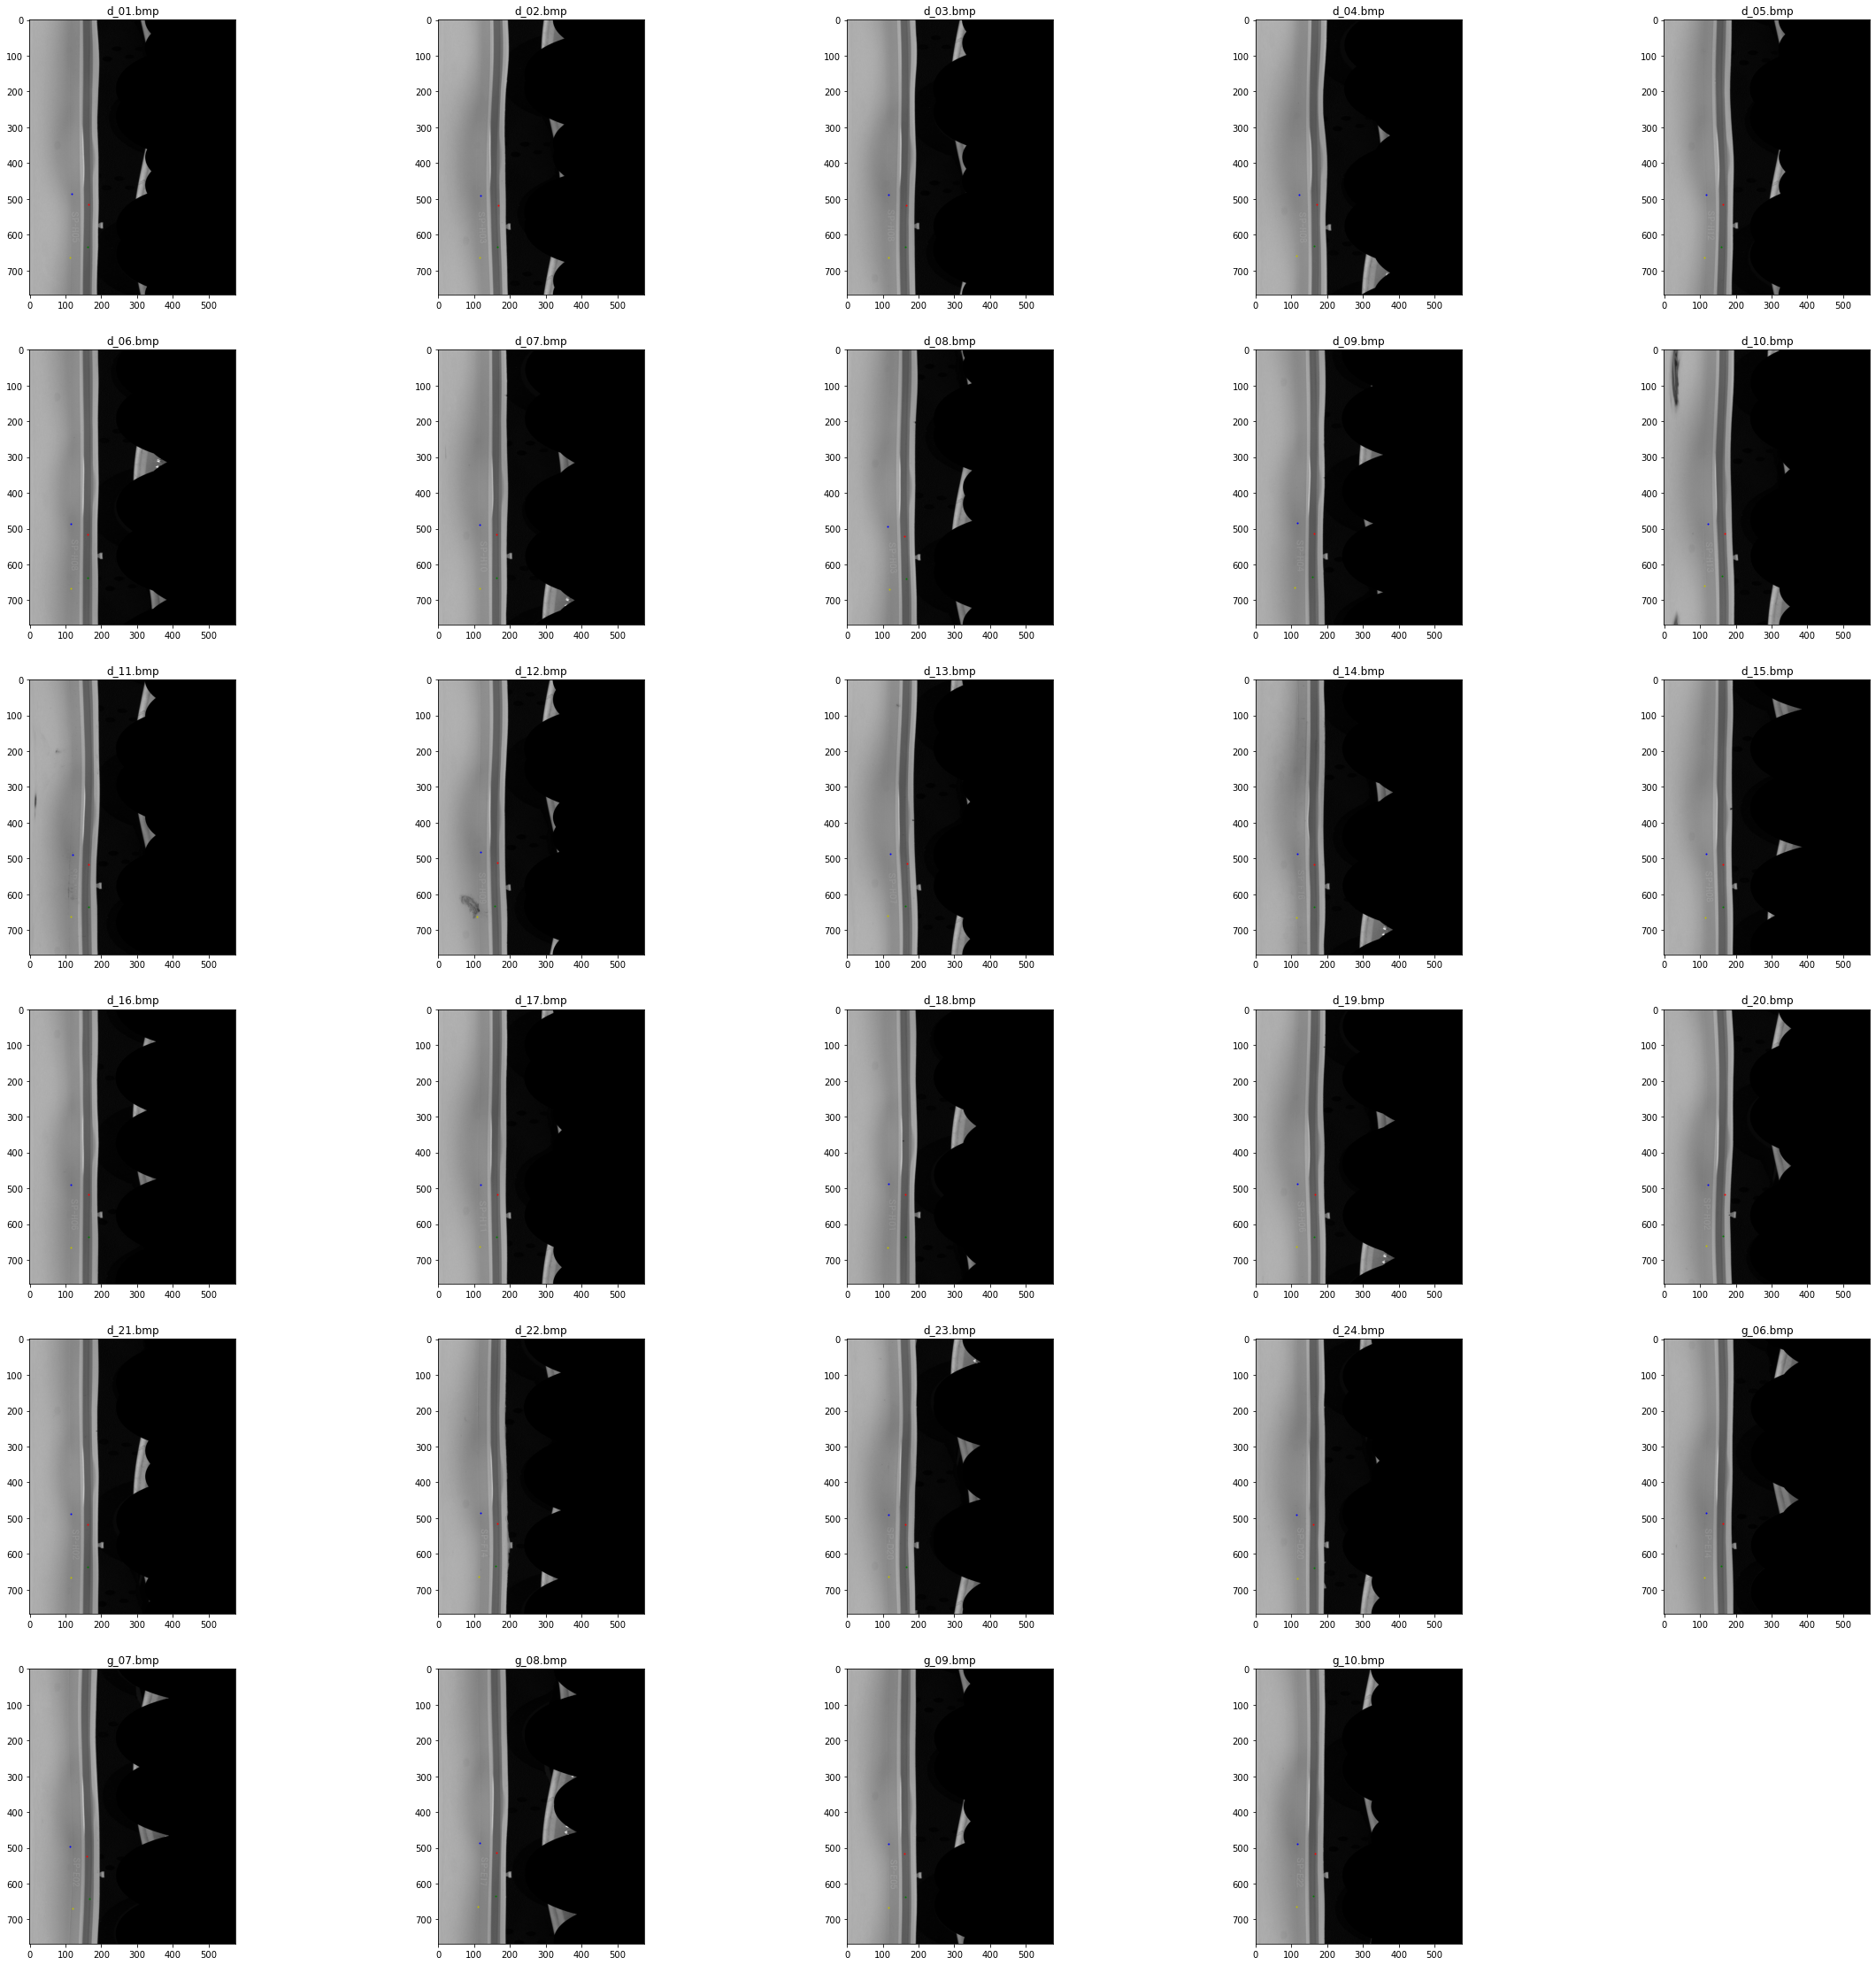

In [122]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    image_with_vertical_tab = rotated_images[i]
    radius = radius_list[i]
    image_center = tuple(np.array(image_with_vertical_tab.shape[1::-1]) / 2)
    cart_corners = cart_corner_coords[i]
     
# first, we create an image highlighting crop corners only  
    img_wcorners = np.zeros(image_with_vertical_tab.shape)
    for j in range(len(cart_corners)):
        img_wcorners[cart_corners[j][0]][cart_corners[0][1]] = 255
        img_wcorners[cart_corners[j][0]][cart_corners[1][1]] = 255
        img_wcorners[cart_corners[j][0]][cart_corners[2][1]] = 255
        img_wcorners[cart_corners[j][0]][cart_corners[3][1]] = 255

    # polar transform -> polar image with crop corners
    polar_corners= cv2.warpPolar(img_wcorners, image_with_vertical_tab.shape, image_center, 3*radius, flags)

    # cartesian corners are "spread" into several very close non-black pixels in the polar image -> we must find 4 of them
    rows_nonzero, cols_nonzero = np.nonzero(polar_corners)
    rows_nonzero = np.unique(rows_nonzero)
    cols_nonzero = np.unique(cols_nonzero)

    row_indexes = []
    col_indexes = []

    # finding 4 distant (several pixels away) row indexes
    min_dist = 12
    for j, index_row in enumerate(rows_nonzero[1:]):
        if index_row > rows_nonzero[j] + min_dist:
            row_indexes.append(rows_nonzero[j])

    row_indexes.append(rows_nonzero[-1])

    # finding column indexes
    for j in row_indexes:
        col_indexes.append(np.nonzero(polar_corners[j])[0][0])
        
    polar_rows_coords.append(row_indexes)
    polar_cols_coords.append(col_indexes)


    # plotting corner points on the polar image
    colors = ["ob", "or", "og", "oy"]
    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(polar_images[i], cmap='gray', vmin=0, vmax=255)

    ax.plot(col_indexes[0], row_indexes[0], colors[0], markersize=1)
    ax.plot(col_indexes[1], row_indexes[1], colors[1], markersize=1)
    ax.plot(col_indexes[2], row_indexes[2], colors[2], markersize=1)
    ax.plot(col_indexes[3], row_indexes[3], colors[3], markersize=1)


plt.show()

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    image_with_vertical_tab = rotated_images[i]
    radius = radius_list[i]
    image_center = tuple(np.array(image_with_vertical_tab.shape[1::-1]) / 2)
    row_indexes = polar_rows_coords[i]
    col_indexes = polar_cols_coords[i]
    polar_image = polar_images[i]
    
    crop_serial = polar_image.copy()[row_indexes[0] : row_indexes[3], col_indexes[0] : col_indexes[1]]
    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(cv2.rotate(crop_serial, cv2.ROTATE_90_COUNTERCLOCKWISE), cmap='gray', vmin=0, vmax=255)

plt.show()


This second approach is more general, but it does not provide optimal results for all images.
Furthermore, it adds non-negligible computational complexity, since a second polar transform needs to be applied on an entire new image.

#### Efficient and more precise solution: warp only the corners defining the bounding box of the crop on the original image
In this solution, we will manually compute the corrisponding position of the corners defining the crop on the original image, applying this relations (accordingly to OpenCV documentation):

$y\_warp = \dfrac{height}{2\pi} \cdot \theta$

$x\_warp = \dfrac{width}{warp\_radius} \cdot ||I||$

with:

- $height$: being the height of the warped image

- $\theta$: being the angle that the corner have with the unit vector pointing to the right (0,1) 

- $width$: being the width of the warped image

- $warp\_radius$: being the radius used while warping the iamge with `cv2.warpPolar()`

- $I$: being the vector that starts from the center of the original image and connects to the corner

In [ ]:
corners = [top_left, bottom_left, bottom_right, top_right] 
warp_radius = 3*radius

def angle_between(vector_1, vector_2):
    v1_u = vector_1 / np.linalg.norm(vector_1)
    v2_u = vector_2 / np.linalg.norm(vector_2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

plt.figure(figsize=(15,15))
ax1 = plt.subplot(1,2,1)

ax1.imshow(rotated_images[0], cmap="gray", vmin=0, vmax=255)
for corner in corners:
    plt.scatter(corner[1],corner[0])

ax2 = plt.subplot(1,2,2)
ax2.imshow(polar_images[0], cmap='gray', vmin=0, vmax=255)

warped_corners = [[],[]]

for corner in corners:
    # TODO: we have to take into consideration to switch either the coords of the corners (which have the y in the first place) or the coords of the center (which have the cols in the first place)
    x = corner[1]-center[0]
    y = corner[0]-center[1]
    corner_wrt_center = (x,y)
    
    """
    The following line computes the angle between a vector that virtually lies from the center to one of the four corners of the crop
    Since the dot product of two vectors is the product of their norms times the cosine of their angles, if we normalize corner_wrt_center
    to the unit norm and we compute the dot product with the normal vector pointing to the right, we get the cosine of the angle between
    them multiplied by 1^2, aka the cosine of the angle between them. At this point we can take the arccos and get the angle in radians.
    The clipping is due to floating point approximation that could cause the dot product to be slightly above (below) 1 (-1)
    """
    angle = 2*np.pi - np.arccos(np.clip(np.dot(corner_wrt_center / np.linalg.norm(corner_wrt_center), (1, 0)), -1.0, 1.0))

    y_warped = (polar_image.shape[0] / (2 * np.pi)) * angle

    x_warped = ((polar_image.shape[1]*1.0) / warp_radius) * np.sqrt(x**2 + y**2)
    warped_corners[0].append(x_warped)
    warped_corners[1].append(y_warped)

    plt.scatter(x_warped, y_warped)


In [125]:
warped_corners_images = []

In [126]:
def find_warped_corners(corners, center, warp_radius):
    warped_corners = [[],[]]

    for corner in corners:
        x = corner[1]-center[0]
        y = corner[0]-center[1]
        corner_wrt_center = (x,y)

        angle = 2*np.pi - np.arccos(np.clip(np.dot(corner_wrt_center / np.linalg.norm(corner_wrt_center), (1, 0)), -1.0, 1.0))

        y_warped = (polar_image.shape[0] / (2 * np.pi)) * angle
        x_warped = ((polar_image.shape[1]*1.0) / warp_radius) * np.sqrt(x**2 + y**2)
        
        warped_corners[0].append(x_warped)
        warped_corners[1].append(y_warped)
    
    return warped_corners

In [ ]:
plt.figure(figsize=(40,40))

for i, file in enumerate(sorted(listdir(mypath))):
    if file.startswith("."):
        continue
    
    image_with_vertical_tab = rotated_images[i]
    image_center = tuple(np.array(image_with_vertical_tab.shape[1::-1]) / 2)
    polar_image = polar_images[i]
    warped_corners = find_warped_corners(corners=cart_corner_coords[i], center=image_center, warp_radius=warp_radius)
    
    ax = plt.subplot(int(np.ceil(len(listdir(mypath))/5)), 5, i+1)
    ax.set_title(file)
    ax.imshow(cv2.rotate(polar_image[int(min(warped_corners[1])):int(max(warped_corners[1])),int(min(warped_corners[0])):int(max(warped_corners[0]))], cv2.ROTATE_90_COUNTERCLOCKWISE), cmap="gray", vmin=0, vmax=255)

plt.show()

## 4: Not required but apply ocr

In [ ]:
from PIL import Image
import pytesseract
pytesseract.image_to_string(
    Image.open('/Users/micheletagliani/Developer/Python/CoputerVision/CvCavityNumberPreprocessing/result.png'),
    config="--psm 7")